# ME 144 / ME 244 — Project 4: Drone flight dynamics and structural simulation

**Name:** Jack Nelson

In [1]:
# Reloads modules as you edit
%load_ext autoreload
%autoreload 2

# Make imports work whether the kernel cwd is repo-root or this folder.
import sys
from pathlib import Path

cwd = Path.cwd()
project4_dir = (cwd / "projects" / "project4") if (cwd / "projects" / "project4").exists() else cwd
if str(project4_dir) not in sys.path:
    sys.path.insert(0, str(project4_dir))

print("cwd:", cwd)
print("project4_dir on sys.path:", project4_dir)


cwd: c:\Users\15593\Desktop\ME144\projects\project4
project4_dir on sys.path: c:\Users\15593\Desktop\ME144\projects\project4


<div style="page-break-after: always;"></div>

## 1. Rigid body assumption and integrators

### 1(a) Rigid body assumption (written)

Prompt: In a few sentences, why is the rigid-body assumption “good enough” for modeling flight dynamics? What advantages does it have over non-rigid modeling approaches, and what is a scenario in which we would want to use a non-rigid model?

**Answer:**
For flight dynamics we typically care about the vehicle’s center-of-mass motion and attitude over time scales where the frame deformations are small compared to the overall geometry. If the structure is stiff enough, elastic vibrations are relatively high-frequency and low-amplitude, so modeling the frame as a rigid body captures the dominant behavior while greatly simplifying the state and equations of motion.
The rigid-body assumption reduces the number of degrees of freedom (6 DOF instead of thousands), makes simulation much faster, and enables simple control design/analysis (linearization, PID/LQR, etc.).
A non-rigid model is needed when flexibility matters: e.g., lightweight/flexible arms that bend under thrust, large payloads causing significant deflection, aeroelastic wings, or to predict resonance/fatigue/failure during aggressive maneuvers or impacts.

<div style="page-break-after: always;"></div>

### 1(b) Explicit Euler rigid-body integrator (written)

Prompt: Complete `step_rigid_body(...)` in `dynamics/integrators.py`.

**Answer / notes:**
Explicit Euler advances the state using the current derivative: $x_{k+1}=x_k+\Delta t\,\dot{x}(x_k)$. For rigid-body dynamics this means updating position by velocity, velocity by acceleration, and attitude/orientation by integrating angular velocity (and updating angular velocity via applied torque and inertia).
It is first-order accurate and conditionally stable, so it generally requires a small time step; it can also introduce numerical energy drift for long runs, but it’s simple and sufficient here with small $\Delta t$.

<div style="page-break-after: always;"></div>

## 2. Quadcopter hovering

### 2(a) Motor forces/torques mapping (written)

Prompt: Complete `forces_and_torques(...)` in `dynamics/quadrotor.py`.

**Answer / notes:**
Each rotor produces an upward thrust along the body $+\hat{z}$ axis. The net force is the sum of all rotor thrusts (plus gravity in the world frame).
The net torque has two parts: (1) roll/pitch torques from the moment arms, $\tau_{rp} = \sum_i r_i \times F_i$, where $r_i$ is the rotor position in the body frame and $F_i$ is the thrust vector; and (2) yaw torque from rotor reaction torques (drag), where counter-rotating rotors contribute opposite signs. The coefficient `k_torque` sets the proportionality between thrust (or rotor command) and reaction torque about body $\hat{z}$.

<div style="page-break-after: always;"></div>

### 2(b) Hover and free-fall (code + required console output)

Prompt: Complete `hover(...)` in `test_scripts/hover_quad.py`, and include console output of the z-position and angular velocity for hover and for free-fall (u = 0).

The next two code cells run (1) hover and (2) free-fall and print the required values.

In [2]:
from geometry.drone_builder import build_simple_quad
from test_scripts.hover_quad import QuadFlight
import numpy as np
from IPython.display import display

quad, state0 = build_simple_quad()
qf = QuadFlight(quad, T=2.0, dt=0.01)

# Hover run (required console output in Q2b)
state_history_hover = qf.hover()

print("\nHover summary:")
print("  final position:", state_history_hover["x"][-1])
print("  final velocity:", state_history_hover["v"][-1])
print("  final omega:", state_history_hover["omega"][-1])

# Animation (should display in-notebook; falls back to JS if ffmpeg isn't available)
display(qf.animate(state_history_hover))


t= 0.00  z= 10.000  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 0.40  z= 10.000  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 0.80  z= 10.000  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 1.20  z= 10.000  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 1.60  z= 10.000  w=[' 0.0000', ' 0.0000', ' 0.0000']

Hover summary:
  final position: [ 0.  0. 10.]
  final velocity: [0. 0. 0.]
  final omega: [0. 0. 0.]


In [3]:
# Free-fall run (u = 0) required by Q2(b)
from IPython.display import display

state = quad.initial_state(position=[0, 0, 10.0])
dt = qf.dt
T = qf.T
steps = int(T / dt)

state_history_freefall = {
    'x': np.zeros((steps, 3)),
    'v': np.zeros((steps, 3)),
    'omega': np.zeros((steps, 3)),
    'R': np.zeros((steps, 3, 3)),
}

print("\n--- Free-fall (all motors off) ---")
for k in range(steps):
    u_zero = np.zeros(4)
    state = quad.step(state, u_zero, dt)
    state_history_freefall['x'][k] = state.position
    state_history_freefall['v'][k] = state.velocity
    state_history_freefall['omega'][k] = state.omega
    state_history_freefall['R'][k] = state.rotation
    if k % 40 == 0:
        print(f"t={k*dt: .2f}  z={state.position[2]: .3f}  w={[f'{w: .4f}' for w in state.omega]}")

print("free-fall final z:", state.position[2])

# This animation should clearly move (accelerating downward).
display(qf.animate(state_history_freefall))



--- Free-fall (all motors off) ---
t= 0.00  z= 10.000  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 0.40  z= 9.196  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 0.80  z= 6.822  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 1.20  z= 2.878  w=[' 0.0000', ' 0.0000', ' 0.0000']
t= 1.60  z=-2.635  w=[' 0.0000', ' 0.0000', ' 0.0000']
free-fall final z: -9.521900000000008


<div style="page-break-after: always;"></div>

### 2(c) Yaw rotation (written)

Prompt: In a few sentences, how would you alter the motor speed input $D$ to produce yaw rotation? What does the coefficient `k_torque` do?

**Answer:**
To produce yaw, keep total thrust roughly constant (to maintain altitude) while creating a nonzero net reaction torque about the body $z$ axis. A common approach is to increase the speeds of the two rotors that spin in one direction and decrease the speeds of the two rotors that spin in the opposite direction by the same amount; the thrust sums approximately cancel, but the reaction torques add.
The coefficient `k_torque` converts rotor thrust/command into an aerodynamic reaction torque (drag) contribution; larger `k_torque` means the same differential rotor command produces a larger yaw moment.

<div style="page-break-after: always;"></div>

## 3. Defining the grid

### 3(a) Grid FD vs FEM (written)

Prompt: Review §4.3. Why is a grid-based finite difference method advantageous over FEM when geometry is given as a voxel grid (§4.2)? What is a possible disadvantage?

**Answer:**
With a voxel grid, the geometry is already aligned to a regular Cartesian lattice, so finite differences are easy to implement: the discretization uses simple local stencils, indexing is straightforward, and assembly/mesh generation is avoided. This makes the method fast and robust for repeated simulations.
A disadvantage is geometric accuracy: curved boundaries become “stair-stepped”, boundary conditions/tractions are harder to apply accurately at irregular surfaces, and you may need a very fine grid to get accurate stresses near boundaries (increasing cost and tightening stability limits on $\Delta t$).

<div style="page-break-after: always;"></div>

### 3(b) Lamé parameters + von Mises (written)

Prompt: Complete missing code in `elastostatics/grid.py` (Lamé parameters and von Mises stress).

**Answer / notes:**
For isotropic linear elasticity, the Lamé parameters are
- $\mu = \dfrac{E}{2(1+\nu)}$ (shear modulus)
- $\lambda = \dfrac{E\,\nu}{(1+\nu)(1-2\nu)}$
The (3D) von Mises stress is computed from the deviatoric stress $s = \sigma - \tfrac{1}{3}\,\mathrm{tr}(\sigma) I$ as
$$\sigma_{VM}=\sqrt{\tfrac{3}{2}\, s:s}.$$

<div style="page-break-after: always;"></div>

## 4. Writing the solver

### 4(a) Linear elasticity solver (written)

Prompt: Fill in `elastostatics/solver.py` to compute strain, stress, divergence, and advance by explicit Euler.

**Answer / notes:**
The solver computes displacement gradients using central differences, forms the infinitesimal strain tensor $\varepsilon = \tfrac{1}{2}(\nabla u + (\nabla u)^T)$, then computes Cauchy stress via Hooke’s law for isotropic materials: $\sigma = 2\mu\varepsilon + \lambda\,\mathrm{tr}(\varepsilon) I$.
The equation of motion is $\rho\,\ddot{u} = \nabla\cdot\sigma$; we compute $\nabla\cdot\sigma$ with central differences and advance by explicit Euler: $v^{n+1}=v^n+\Delta t\,a^n$, $u^{n+1}=u^n+\Delta t\,v^{n+1}$.
A CFL-like stability limit ties $\Delta t$ to grid spacing and elastic wave speed, and added damping helps the transient dynamics settle toward the static solution.

<div style="page-break-after: always;"></div>

### 4(b) Stress field evolution (code + required outputs + written)

Run the uniaxial tension validation using the provided script entrypoint `test_scripts/uniaxial_tension_test.py`.

Required outputs:
- Screenshot of your stress field at step 500
- Console output at step 3000

**Answer (what to notice):**
The von Mises field starts with boundary-driven transients and stress waves that propagate through the block. With damping, kinetic energy decays and the oscillations settle; the stress distribution approaches a near-steady state and the center $\sigma_{zz}$ converges close to the analytical value $E\,\varepsilon_{zz}$.

Bar length : 9.0 mm
max wavespeed        : 34.64 m/s
dt         : 2.887e-06 s
damping    : 3849.0 (50% of critical 7698.0)
sigma_zz (analytical) : 5000.00 Pa
Total steps: 3000

step     0 | sigma_zz (center) = 0.0000e+00 Pa | error = 100.00% | KE = 9.99e+01
step   100 | sigma_zz (center) = 1.3465e+03 Pa | error = 73.07% | KE = 2.52e+03
step   200 | sigma_zz (center) = 4.7690e+03 Pa | error = 4.62% | KE = 7.26e+02
step   300 | sigma_zz (center) = 4.4619e+03 Pa | error = 10.76% | KE = 1.94e+02
step   400 | sigma_zz (center) = 4.6998e+03 Pa | error = 6.00% | KE = 1.29e+02
step   500 | sigma_zz (center) = 4.5985e+03 Pa | error = 8.03% | KE = 6.38e+01
step   600 | sigma_zz (center) = 4.8658e+03 Pa | error = 2.68% | KE = 2.34e+01
step   700 | sigma_zz (center) = 4.9678e+03 Pa | error = 0.64% | KE = 8.70e+00
step   800 | sigma_zz (center) = 5.0060e+03 Pa | error = 0.12% | KE = 3.90e+00
step   900 | sigma_zz (center) = 4.9837e+03 Pa | error = 0.33% | KE = 1.48e+00
step  1000 | sigma_zz (center

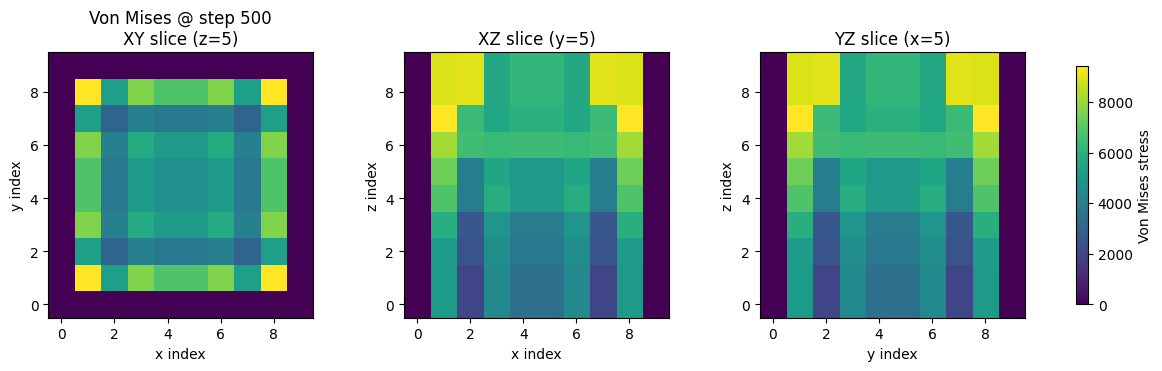

In [4]:
# Q4(b) — Cube/bar uniaxial tension validation 
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from elastostatics.grid import ElasticGrid
import elastostatics.solver as solver
# Import from the canonical entrypoint name used in the assignment handout
from test_scripts.uniaxial_tension_test import init_von_mises_3d_animation

# Material + grid parameters 
E = 1e6          # Young's modulus [Pa]
nu = 0.25         # Poisson ratio
rho = 1000.0      # density [kg/m^3]
h = 0.001         # node spacing [m]
nx = ny = nz = 10
eps_zz = 0.005    # applied axial strain (0.5%)

grid = ElasticGrid(
    shape=(nx, ny, nz),
    spacing=(h, h, h),
    density=rho,
    young=E,
    poisson=nu,
 )

# Physical bar length: node 0 to node nz-1
L_bar = (nz - 1) * h
target_disp = eps_zz * L_bar
sig_analytical = E * eps_zz

# Time step (CFL) and damping
dt = solver.compute_stable_dt(grid, safety_factor=0.1)
c_p = solver.compute_max_wavespeed(grid.lam, grid.mu, grid.rho)
critical_damping = 2 * c_p / max(L_bar, 1e-12)
damping = 0.5 * critical_damping
total_steps = 3000

print(f"Bar length : {L_bar*1e3:.1f} mm")
print(f"max wavespeed        : {c_p:.2f} m/s")
print(f"dt         : {dt:.3e} s")
print(f"damping    : {damping:.1f} (50% of critical {critical_damping:.1f})")
print(f"sigma_zz (analytical) : {sig_analytical:.2f} Pa")
print(f"Total steps: {total_steps}\n")

def apply_bcs(g: ElasticGrid):
    # z-displacement BCs: clamp bottom face, prescribe top face displacement
    g.u[:, :, 0, 2] = 0.0
    g.v[:, :, 0, :] = 0.0
    g.u[:, :, -1, 2] = target_disp
    g.v[:, :, -1, 2] = 0.0

# Monitor center stress for the analytical check
ic = nx // 2
jc = ny // 2
kc = nz // 2

# Animation capture 
update_3d, render_3d = init_von_mises_3d_animation(grid)
anim_stride = 25
anim_max_step = 500

step500_vm = None
for n in range(total_steps + 1):
    solver.step_elastic_grid(grid, dt, damping=damping, enforce_bc=apply_bcs)

    if n <= anim_max_step and n % anim_stride == 0:
        update_3d(n)

    if n == 500:
        step500_vm = grid.calc_von_mises().copy()

    if n % 100 == 0 or n == total_steps:
        KE = 0.5 * rho * float(np.sum(grid.v ** 2))
        sigzz = float(grid.sigma[ic, jc, kc, 2, 2])
        error = abs(sigzz - sig_analytical) / sig_analytical * 100
        print(
            f"step {n:5d} | sigma_zz (center) = {sigzz:.4e} Pa "
            f"| error = {error:.2f}% | KE = {KE:.2e}"
        )

assert step500_vm is not None

# --- Required: stress-field snapshot at step 500
vm = step500_vm
ix, iy, iz = nx // 2, ny // 2, nz // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
axes[0].imshow(vm[:, :, iz].T, origin="lower", cmap="viridis")
axes[0].set_title(f"Von Mises @ step 500\nXY slice (z={iz})")
axes[0].set_xlabel("x index")
axes[0].set_ylabel("y index")
axes[1].imshow(vm[:, iy, :].T, origin="lower", cmap="viridis")
axes[1].set_title(f"XZ slice (y={iy})")
axes[1].set_xlabel("x index")
axes[1].set_ylabel("z index")
im2 = axes[2].imshow(vm[ix, :, :].T, origin="lower", cmap="viridis")
axes[2].set_title(f"YZ slice (x={ix})")
axes[2].set_xlabel("y index")
axes[2].set_ylabel("z index")
fig.colorbar(im2, ax=axes, shrink=0.9, label="Von Mises stress")
plt.show()

# Animation 
display(render_3d())

<div style="page-break-after: always;"></div>

### 4(c) Euler vs. Lagrange (written)

Prompt: In a sentence, are we using an Eulerian or Lagrangian approach to modeling? How do you know?

**Answer:**
Eulerian: the solver stores and updates fields on a fixed grid in space (the voxel lattice does not move), and we compute displacements/stresses at those fixed grid locations over time.